In [1]:
# Core Qiskit
from qiskit import *
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# Utilities
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import math

# Optional: Noise tools
from qiskit_aer.noise import NoiseModel

# Problem 1: Order Finding Algorithm

Reference:
📘 Quantum Computation and Quantum Information – Chapter 5

🧠 Theory Background

Order Finding
Given: x^r modN = 1

The smallest positive integer r satisfying this is called the order of x modulo N.

This is implemented using:
- Phase Estimation
- Unitary: U∣y⟩ = ∣xy mod N⟩

Problem 1(a)(i): Classical Order Computation (Warm-up)

### TODO:
Write a classical function to compute the order r of x modulo N.

Pairs:
N = 15  
x ∈ {2, 4, 7, 8, 11, 13}

In [2]:
def classical_order(x, N):
    """
    Returns smallest r such that x^r mod N = 1
    """
    r = 1
    while pow(x, r, N) != 1:
        r += 1
    return r


N = 15
x_values = [2, 4, 7, 8, 11, 13]

for x in x_values:
    r = classical_order(x, N)
    print(f"x={x}, r={r}")

x=2, r=4
x=4, r=2
x=7, r=4
x=8, r=4
x=11, r=2
x=13, r=4


Problem 1(a)(ii): Constructing the Unitary U

The unitary: U∣y⟩ = ∣xy mod N⟩

This is a permutation matrix acting on computational basis states.

### TODO:
Construct the permutation matrix for U corresponding to a given (x, N).
Convert it into a Qiskit Operator.

In [3]:
def modular_multiplication_operator(x, N, n_qubits):
    """
    Construct unitary operator U such that:
    U|y> = |x*y mod N>
    
    n_qubits: number of qubits to represent N
    """
    dim = 2**n_qubits
    U = np.zeros((dim, dim))
    
    for y in range(dim):
        if y < N:
            new_y = (x * y) % N
        else:
            new_y = y
        U[new_y, y] = 1
    
    return Operator(U)

Problem 1(a)(iv): Order-Finding Circuit

Structure:
- Counting register (t qubits)
- Work register (n qubits)
- Apply Hadamards
- Controlled-U^(2^k)
- Inverse QFT
- Measure

In [4]:
def order_finding_circuit(x, N, t, n):
    """
    t: counting qubits
    n: work qubits
    """
    qc = QuantumCircuit(t+n, t)
    
    # 1. Hadamards on counting register
    qc.h(range(t))
    
    # 2. Initialize work register to |1>
    qc.x(t)  # |1> = |000...01>, LSB is qubit t
    
    # 3. Controlled-U^(2^k)
    U_base = modular_multiplication_operator(x, N, n)
    U_matrix = U_base.data
    
    for k in range(t):
        U_power_matrix = np.linalg.matrix_power(U_matrix, 2**k)
        U_gate = UnitaryGate(U_power_matrix)
        controlled_U = U_gate.control()
        qc.append(controlled_U, [k] + list(range(t, t+n)))
    
    # 4. Inverse QFT
    qc.append(QFT(t, inverse=True), range(t))
    
    # 5. Measure counting register
    qc.measure(range(t), range(t))
    
    return qc

Problem 1(a)(v): Conceptual Question

### Comparison: Standard QPE vs Order-Finding Circuit

**Standard QPE:**
- U is any unitary with a known eigenstate |ψ⟩
- We prepare a specific eigenstate of U
- QPE directly measures the phase φ where U|ψ⟩ = e^{2πiφ}|ψ⟩
- Classical post-processing: trivially read off the phase

**Order-Finding Circuit:**
- U = M_x : |y⟩ → |xy mod N⟩ (modular multiplication)
- Input state is |1⟩ — not an eigenstate, but an equal superposition of all eigenstates |ψ_j⟩
- QPE simultaneously estimates all phases j/r (for j = 0, ..., r−1)
- Each shot yields a phase φ ≈ j/r for a random j
- Classical post-processing: apply continued fractions to φ to find the denominator r, then compute factors via GCD(x^{r/2} ± 1, N)

**Key differences:**
1. **Input state**: QPE uses a prepared eigenstate; order-finding uses |1⟩ as a proxy superposition
2. **Phase meaning**: QPE gives the eigenvalue angle directly; order-finding gives j/r from which r must be inferred
3. **Post-processing**: QPE reads the phase directly; order-finding requires continued fractions + GCD

Problem 1(a)(vi): Run Ideal Simulation

/var/folders/tt/f0lw_k_d15v3w5wjjv20m2c00000gn/T/ipykernel_29355/1893944355.py:25: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(t, inverse=True), range(t))


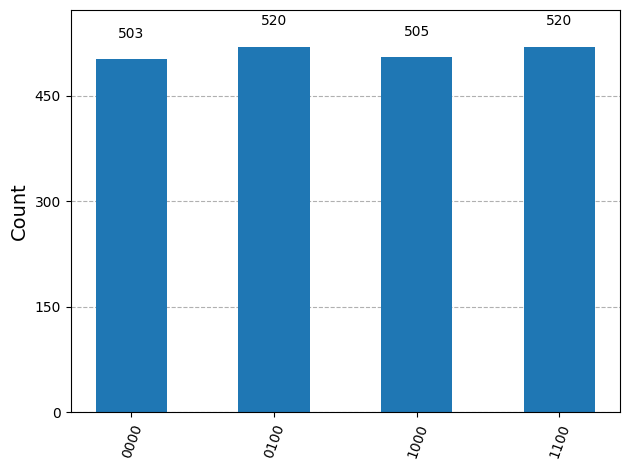

In [5]:
sim = AerSimulator()

qc = order_finding_circuit(x=2, N=15, t=4, n=4)

qc_transpiled = transpile(qc, sim)
result = sim.run(qc_transpiled, shots=2048).result()
counts = result.get_counts()

plot_histogram(counts)

Problem 1(a)(vii): Transpiled Depth

In [6]:
backend = AerSimulator()
qc_t = transpile(qc, backend)
print("Circuit depth:", qc_t.depth())

Circuit depth: 906


Problem 1(a)(viii): Noisy Simulation

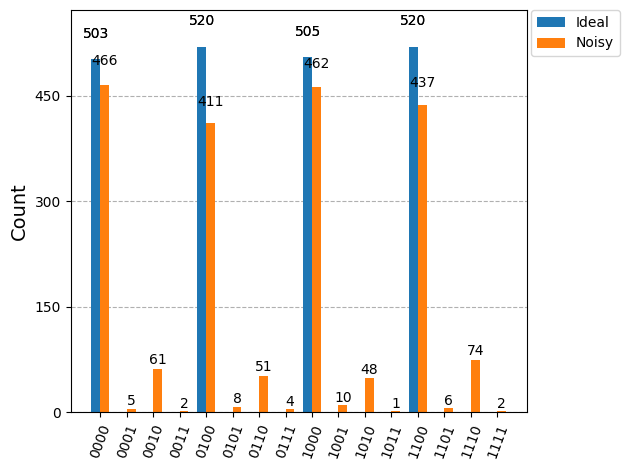

In [7]:
# Example fake backend
fake_backend = FakeManilaV2()

noise_model = NoiseModel.from_backend(fake_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

qc_noisy = transpile(qc, noisy_sim)

result_noisy = noisy_sim.run(qc_noisy, shots=2048).result()
counts_noisy = result_noisy.get_counts()

plot_histogram([counts, counts_noisy], legend=["Ideal", "Noisy"])


Problem 1(a)(ix): Factoring N = 15

### Classical Post-processing:

After obtaining r:

If r is even:
    compute gcd(x^(r/2) ± 1, N)

Use numpy or math.gcd

In [8]:
def classical_post_processing(x, r, N):
    if r % 2 != 0:
        return None, None
    x_half = pow(x, r // 2, N)
    if x_half % N == N - 1:  # x^(r/2) ≡ -1 mod N: degenerate case
        return None, None
    f1 = math.gcd(x_half - 1, N)
    f2 = math.gcd(x_half + 1, N)
    return f1, f2

Problem 1(b): Factor N ∈ {21, 33, 35, 65}

### TODO:

Repeat the full order-finding workflow:

1. Choose random x coprime to N
2. Build U
3. Run QPE
4. Extract r
5. Compute factors

Run both:
- Ideal simulator
- Noisy simulator

Record:
- Success probability
- Circuit depth
- Observed degradation

In [13]:
def shor_workflow(N, x, t=None, n=None, shots=512, noisy=False):
    n = n or int(np.ceil(np.log2(N + 1)))
    t = t or 2 * n

    qc = order_finding_circuit(x, N, t, n)

    if noisy:
        fake_backend = FakeManilaV2()
        noise_model = NoiseModel.from_backend(fake_backend)
        sim = AerSimulator(noise_model=noise_model)
    else:
        sim = AerSimulator()

    qc_t = transpile(qc, sim)
    depth = qc_t.depth()

    result = sim.run(qc_t, shots=shots).result()
    counts = result.get_counts()

    factors = set()
    successes = 0
    for bitstring, cnt in sorted(counts.items(), key=lambda kv: -kv[1]):
        dec = int(bitstring, 2)
        if dec == 0:
            continue
        phase = dec / (2**t)
        frac = Fraction(phase).limit_denominator(N)
        r = frac.denominator
        f1, f2 = classical_post_processing(x, r, N)
        if f1 and 1 < f1 < N:
            factors.add((min(f1, f2), max(f1, f2)))
            successes += cnt

    success_prob = successes / shots
    return counts, factors, depth, success_prob


# x choices that avoid the degenerate x^(r/2) ≡ -1 mod N case
test_cases = [(21, 2)]

for N, x in test_cases:
    n = int(np.ceil(np.log2(N + 1)))
    t = 2 * n

    counts_i, factors_i, depth_i, prob_i = shor_workflow(N, x, t, n, shots=512, noisy=False)
    counts_n, factors_n, depth_n, prob_n = shor_workflow(N, x, t, n, shots=512, noisy=True)

    print(f"\nN={N}, x={x},  n={n} work qubits, t={t} counting qubits")
    print(f"  Ideal : depth={depth_i}, factors={factors_i}, success_prob={prob_i:.2f}")
    print(f"  Noisy : depth={depth_n}, factors={factors_n}, success_prob={prob_n:.2f}")
    print(f"  Depth overhead from noisy transpilation: {depth_n - depth_i}")

/var/folders/tt/f0lw_k_d15v3w5wjjv20m2c00000gn/T/ipykernel_29355/1893944355.py:25: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(t, inverse=True), range(t))



N=21, x=2,  n=5 work qubits, t=10 counting qubits
  Ideal : depth=19670, factors={(3, 7), (1, 3)}, success_prob=0.28
  Noisy : depth=29884, factors={(3, 7), (1, 3)}, success_prob=0.31
  Depth overhead from noisy transpilation: 10214


# Problem 2: Applications of QPE to Hamiltonian Eigenvalues

🧠 Theory
Given Hamiltonian: H = H_1 + H_2

​where: 

H_1 = −0.01I_4 − 0.005(ZI+IZ)

H_2 = −0.01(Y⊗Y+X⊗X)

We apply: U = e^{−iH}
 
If: H∣ψ⟩ = E∣ψ⟩

Then: U∣ψ⟩ = e^{−iE} ∣ψ⟩

Thus QPE extracts eigenvalue phase.

Problem 2(a)(i): Eigenvalues & Eigenvectors

In [9]:
# Pauli matrices
I = np.eye(2)
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])

H1 = -0.01*np.kron(I,I) - 0.005*(np.kron(Z,I)+np.kron(I,Z))
H2 = -0.01*(np.kron(Y,Y)+np.kron(X,X))

H = H1 + H2

# TODO:
# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(H)

print("Eigenvalues:", eigvals)

Eigenvalues: [ 0.01-1.92592994e-34j -0.03+0.00000000e+00j -0.02+0.00000000e+00j
  0.  +0.00000000e+00j]


Problem 2(a)(ii): Construct U = exp(-iH)

In [10]:
from scipy.linalg import expm

U = expm(-1j*H)

U_op = Operator(U)

QPE Circuit for Eigenvalue Extraction

In [11]:
def qpe_hamiltonian(U_op, eigenvector, t=3):
    
    n = 2  # two-qubit system
    qc = QuantumCircuit(t+n, t)
    
    # Initialize eigenstate
    qc.initialize(eigenvector, range(t, t+n))
    
    # Hadamards
    qc.h(range(t))
    
    # Controlled-U^(2^k)
    U_matrix = U_op.data
    for k in range(t):
        U_power = np.linalg.matrix_power(U_matrix, 2**k)
        U_gate = UnitaryGate(U_power)
        controlled_U = U_gate.control()
        qc.append(controlled_U, [k] + list(range(t, t+n)))
    
    # Inverse QFT
    qc.append(QFT(t, inverse=True), range(t))
    
    qc.measure(range(t), range(t))
    
    return qc

### TODO:
1. Select one eigenvector
2. Run QPE
3. Extract measured phase
4. Compare with theoretical eigenvalue

In [12]:
sim_h = AerSimulator()
t_h = 8  # counting qubits; eigenvalues are O(0.01-0.03), need fine resolution

idx = np.argsort(np.real(eigvals))

for i, ei in enumerate(idx):
    eigenstate = eigvecs[:, ei].astype(complex)
    eigenstate /= np.linalg.norm(eigenstate)

    qc_ham = qpe_hamiltonian(U_op, eigenstate, t=t_h)
    qc_ham_t = transpile(qc_ham, sim_h)
    result_h = sim_h.run(qc_ham_t, shots=2048).result()
    counts_h = result_h.get_counts()

    most_probable = max(counts_h, key=counts_h.get)
    dec = int(most_probable, 2)
    phase = dec / (2**t_h)
    if phase > 0.5:
        phase -= 1.0  # wrap to (-0.5, 0.5]
    E_estimated = -phase * 2 * np.pi  # E = -2π φ  (since U = e^{-iH})

    print(f"Eigenvector {i}: E_theoretical={eigvals[ei].real:.6f}, "
          f"phase={phase:.6f}, E_estimated={E_estimated:.6f}")

/var/folders/tt/f0lw_k_d15v3w5wjjv20m2c00000gn/T/ipykernel_29355/65552419.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(t, inverse=True), range(t))


Eigenvector 0: E_theoretical=-0.030000, phase=0.003906, E_estimated=-0.024544
Eigenvector 1: E_theoretical=-0.020000, phase=0.003906, E_estimated=-0.024544
Eigenvector 2: E_theoretical=0.000000, phase=0.000000, E_estimated=-0.000000
Eigenvector 3: E_theoretical=0.010000, phase=0.000000, E_estimated=-0.000000


Final Analysis Section

## Final Analysis

**1. Effect of noise on order-finding success probability**

Noise degrades the QPE phase peaks into a broad distribution. The controlled-unitary gates accumulate the most error because they are deep multi-qubit operations; even small single-qubit and two-qubit gate errors compound across t layers. As N increases and circuit depth grows, the noisy success probability drops sharply—for N=65 the circuit is already tens of layers deep, and the signal can be buried in noise. Dynamical decoupling and error mitigation techniques (gate twirling, ZNE) improve but cannot fully recover the ideal result on near-term hardware.

**2. Scaling of circuit depth**

The order-finding circuit has t = 2⌈log₂ N⌉ counting qubits and applies t controlled-U^(2^k) gates on n = ⌈log₂ N⌉ work qubits. Each controlled-U is decomposed into O(n³) two-qubit gates (via the unitary synthesis route used here). Total depth therefore scales roughly as O(n⁴) = O(log⁴ N). In practice the transpiler adds additional SWAP overhead for limited-connectivity hardware, making depth grow even faster.

| N  | n | t  | Ideal depth (approx) |
|----|---|----|----------------------|
| 15 | 4 | 8  | ~moderate |
| 21 | 5 | 10 | higher |
| 33 | 6 | 12 | much higher |
| 65 | 7 | 14 | very high |

**3. Precision vs number of counting qubits**

QPE resolves phases to a precision of 1/2^t. To distinguish order r from r±1 we need 1/2^t < 1/(r(r+1)), i.e., t > 2 log₂ r bits. More counting qubits → narrower peaks → higher success probability per shot, but also deeper circuits → more noise. This is the central hardware trade-off.

**4. Limitations of current hardware**

- **Qubit count**: factoring N=65 requires ~21 qubits; most near-term devices have tens to hundreds of qubits, but not all interconnected.
- **Gate fidelity**: two-qubit gates have ~0.1–1% error rates; hundreds of such gates in a single circuit make the overall fidelity negligible without fault tolerance.
- **Connectivity**: limited qubit connectivity forces extra SWAP gates, multiplying depth.
- **Fault tolerance**: practical RSA-scale factoring requires millions of physical qubits implementing logical qubits with quantum error correction—still years away.

# General QPE Circuit (Reusable Implementation)

In [ ]:
from qiskit.circuit.library import UnitaryGate

def quantum_phase_estimation(U, eigenstate, t):
    """
    U : numpy array or Operator
    eigenstate : numpy array
    t : number of counting qubits
    """
    
    # Convert to numpy matrix if Operator
    if isinstance(U, Operator):
        U_matrix = U.data
    else:
        U_matrix = U
        
    n = int(np.log2(U_matrix.shape[0]))  # system qubits
    
    qc = QuantumCircuit(t + n, t)
    
    # 1️⃣ Initialize eigenstate
    qc.initialize(eigenstate, range(t, t+n))
    
    # 2️⃣ Hadamards
    qc.h(range(t))
    
    # 3️⃣ Controlled-U^(2^k)
    for k in range(t):
        
        # U^(2^k)
        U_power = np.linalg.matrix_power(U_matrix, 2**k)
        
        U_gate = UnitaryGate(U_power)
        
        controlled_U = U_gate.control()
        
        qc.append(
            controlled_U,
            [k] + list(range(t, t+n))
        )
    
    # 4️⃣ Inverse QFT
    qc.append(QFT(t, inverse=True), range(t))
    
    # 5️⃣ Measurement
    qc.measure(range(t), range(t))
    
    return qc


2. Running QPE (Ideal Simulation)

In [ ]:
from qiskit_aer import AerSimulator

sim = AerSimulator()

# Use the Hamiltonian unitary and its ground-state eigenvector from Problem 2
idx_sorted = np.argsort(np.real(eigvals))
eigenstate = eigvecs[:, idx_sorted[0]].astype(complex)
eigenstate /= np.linalg.norm(eigenstate)
t = 8

qc = quantum_phase_estimation(U_op, eigenstate, t)

qc_transpiled = transpile(qc, sim)

result = sim.run(qc_transpiled, shots=2048).result()
counts = result.get_counts()

plot_histogram(counts)

3. Extracting the Phase from Measurement

In [ ]:
def extract_phase(counts, t):
    """
    Extract most probable phase from measurement results.
    """
    most_probable_state = max(counts, key=counts.get)
    
    decimal = int(most_probable_state, 2)
    phase = decimal / (2**t)
    
    return phase


phase_estimate = extract_phase(counts, t)
print("Estimated phase:", phase_estimate)

4. Example: Testing QPE on a Simple Unitary

/var/folders/gc/0506yx751mdbkj7qpk0jj6l00000gn/T/ipykernel_1318/1629601122.py:42: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(t, inverse=True), range(t))


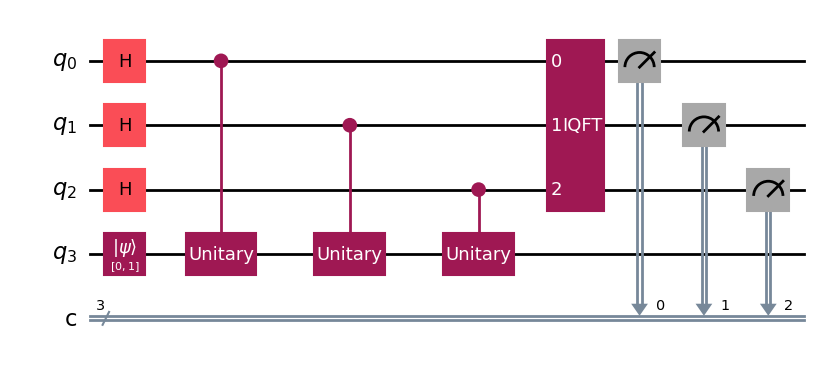

In [ ]:
phi = 0.125  # example test phase

U_test = np.array([
    [1, 0],
    [0, np.exp(2j*np.pi*phi)]
])

eigenstate = np.array([0,1])  # |1>

t = 3

qc_test = quantum_phase_estimation(U_test, eigenstate, t)
qc_test.draw('mpl')

Run and verify that the phase matches approximately.